In [ ]:
import os
import dotenv
import pandas as pd
import mlflow
import mlflow.sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

datapath = "../data/point_samples.csv"
SEED = 42
np.random.seed(SEED)

dotenv.load_dotenv()

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("MyLinearRegression-experimentation")
mlflow.sklearn.autolog(log_models=True, exclusive=False)


df = pd.read_csv(datapath,usecols = ["x","y"])

df_train, df_test = train_test_split(df, test_size=0.2, random_state=SEED)

X_train = df_train[["x"]]
y_train = df_train["y"]
X_test = df_test[["x"]]
y_test = df_test["y"]

params = {"fit_intercept": True}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression(**params))
])


with mlflow.start_run():
    mlflow.log_param("random_state", SEED)
    pipeline.fit(X_train, y_train)


    # Calculate metrics
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Log manually with custom keys
    mlflow.log_metrics({
        "train_mae": mean_absolute_error(y_train, y_pred_train),
        "val_mae": mean_absolute_error(y_test, y_pred_test),
        "train_r2": r2_score(y_train, y_pred_train),
        "val_r2": r2_score(y_test, y_pred_test)
    })


2026/03/04 16:12:54 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: module 'mlflow' has no attribute 'MlflowClient'


🏃 View run abrasive-carp-460 at: http://localhost:5000/#/experiments/2/runs/2b5bf8fdb25c4222be873d0080b4bc67
🧪 View experiment at: http://localhost:5000/#/experiments/2


c:\Users\jjaramil\AppData\Local\anaconda3\envs\agents_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


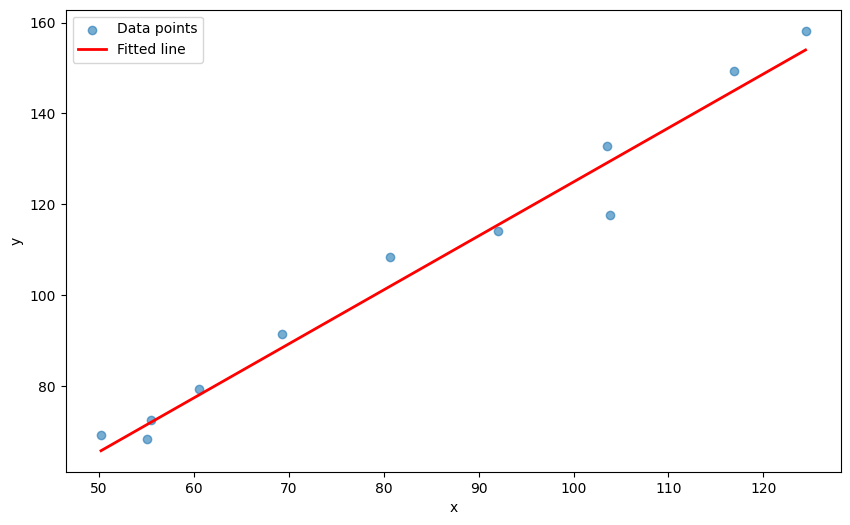

In [3]:

line_x = np.linspace(df["x"].min(), df["x"].max(), 100).reshape(-1, 1)
line_y = pipeline.predict(line_x)

plt.figure(figsize=(10, 6))
plt.scatter(df["x"], df["y"], label='Data points', alpha=0.6)
plt.plot(line_x, line_y, color='red', label='Fitted line', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()